<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_ml/ml10_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree(의사결정 나무)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_validate, cross_val_score  # 교차 검증
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV  # 하이퍼 파라미터 튜닝

# 데이터 셋 준비

wine 데이터 셋 - red vs white wine 분류

In [2]:
file_path = 'https://bit.ly/wine_csv_data'
# https://raw.githubusercontent.com/rickiepark/hg-mldl/master/wine.csv

In [3]:
wine_df = pd.read_csv(file_path)

In [4]:
wine_df.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [5]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


# 데이터 탐색

In [6]:
wine_df.describe()  # 기술 통계량

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


In [12]:
wine_df['class'].unique()  # 범주(카테고리)

array([0., 1.])

*   class 빈도수 막대 그래프

In [14]:
wine_df['class'].value_counts()  #> class 0 = red wine, class 1 = white wine

,count
class,
1.0,4898
0.0,1599


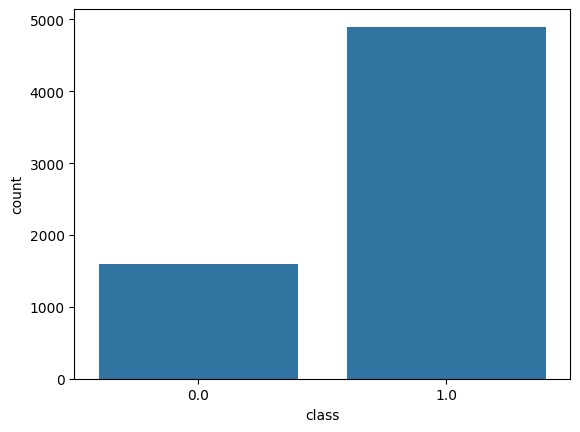

In [13]:
sns.countplot(data=wine_df, x='class')
plt.show()

*   3개 변수(alcohol, sugar, pH) 히스토그램
*   pairplot(각 변수들의 상관관계)

In [18]:
feature_names = wine_df.columns[:-1]
print(feature_names)

Index(['alcohol', 'sugar', 'pH'], dtype='object')


In [19]:
target_names = ['red', 'white']
print(target_names)

['red', 'white']


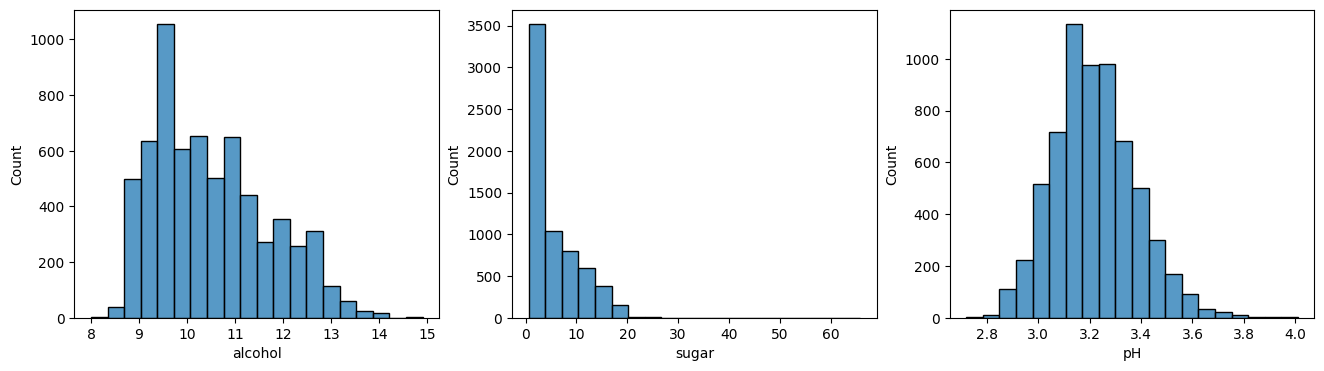

In [23]:
fig, axes = plt.subplots(ncols=3, figsize=(16, 4))

for i, var in enumerate(feature_names):
    sns.histplot(data=wine_df, x=var, ax=axes[i], bins=20)

plt.show()

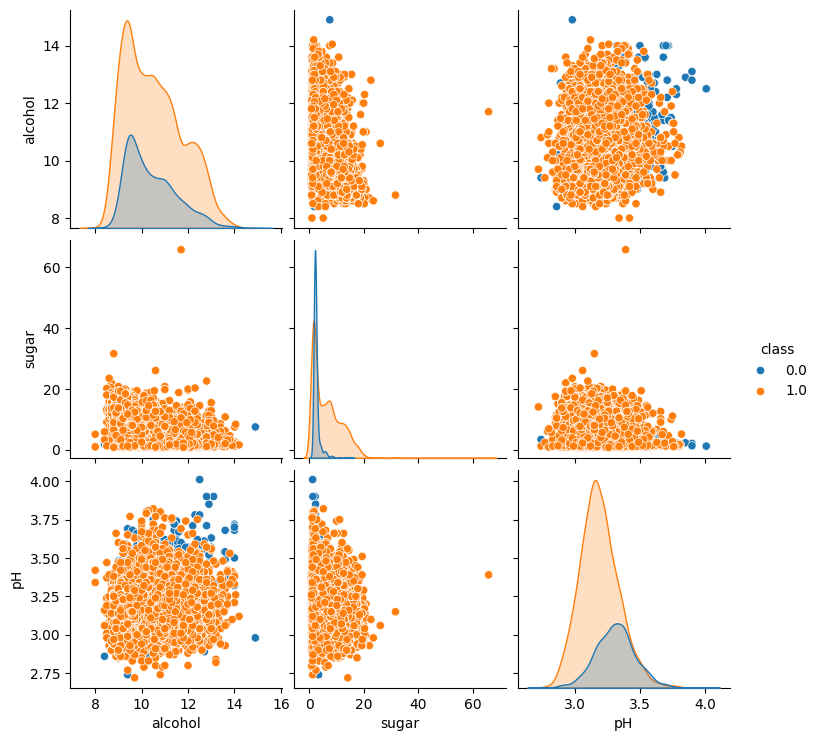

In [24]:
sns.pairplot(data=wine_df, hue='class')
plt.show()

# 훈련 셋 vs 테스트 셋 나누기

In [27]:
x = wine_df[feature_names].values  # 특성(featues) 배열
y = wine_df['class'].values  # 타겟 배열

In [28]:
x.shape, y.shape

((6497, 3), (6497,))

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

In [30]:
x_train.shape, x_test.shape

((5197, 3), (1300, 3))

# Decision Tree Classifier

In [31]:
tree = DecisionTreeClassifier(random_state=42)  # Decisin Tree ML 모델 생성

In [32]:
tree.fit(X=x_train, y=y_train)  # ML 모델 훈련(데이터 학습)

DecisionTreeClassifier(random_state=42)

In [33]:
train_pred = tree.predict(X=x_train)  # 훈련 셋 예측값
print(train_pred[:10])

[1. 1. 1. 0. 0. 0. 1. 1. 1. 0.]


In [34]:
print(y_train[:10])

[1. 1. 1. 0. 0. 0. 1. 1. 1. 0.]


In [35]:
print(classification_report(y_true=y_train, y_pred=train_pred,
                            target_names=target_names))

              precision    recall  f1-score   support

         red       0.99      1.00      1.00      1279
       white       1.00      1.00      1.00      3918

    accuracy                           1.00      5197
   macro avg       1.00      1.00      1.00      5197
weighted avg       1.00      1.00      1.00      5197



In [36]:
train_cm = confusion_matrix(y_true=y_train, y_pred=train_pred)
print(train_cm)

[[1276    3]
 [   8 3910]]


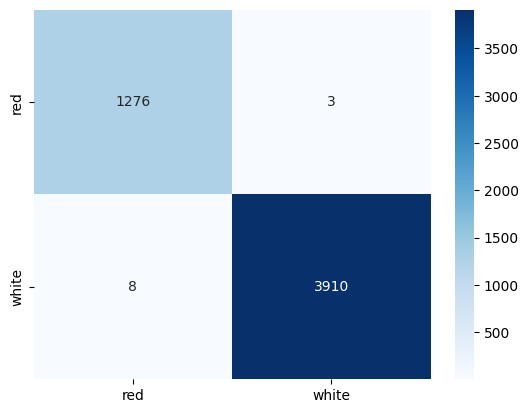

In [38]:
sns.heatmap(data=train_cm, cmap='Blues', annot=True, fmt='.0f',
            xticklabels=target_names, yticklabels=target_names)
plt.show()

In [39]:
test_pred = tree.predict(X=x_test)  # 테스트 셋 예측값
print(test_pred[:10])

[0. 1. 1. 1. 1. 1. 0. 1. 1. 1.]


In [40]:
print(y_test[:10])

[1. 1. 1. 1. 1. 0. 0. 1. 1. 1.]


In [41]:
print(classification_report(y_true=y_test, y_pred=test_pred,
                            target_names=target_names))

              precision    recall  f1-score   support

         red       0.74      0.71      0.72       320
       white       0.91      0.92      0.91       980

    accuracy                           0.87      1300
   macro avg       0.82      0.81      0.82      1300
weighted avg       0.86      0.87      0.86      1300



Decision Tree 모델은 **과대적합(over-fitting)** 이 매우 큼.

In [42]:
test_cm = confusion_matrix(y_true=y_test, y_pred=test_pred)
print(test_cm)

[[226  94]
 [ 81 899]]


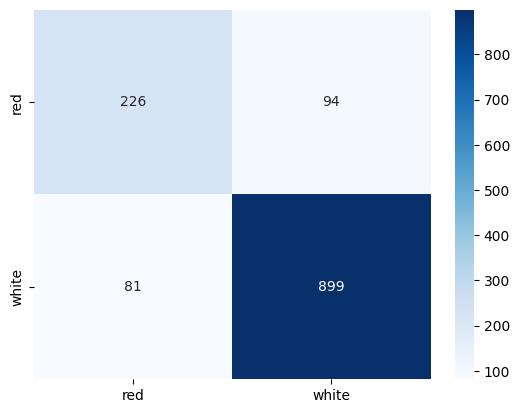

In [43]:
sns.heatmap(data=test_cm, cmap='Blues', annot=True, fmt='.0f',
            xticklabels=target_names, yticklabels=target_names)
plt.show()

# Decision Tree 시각화

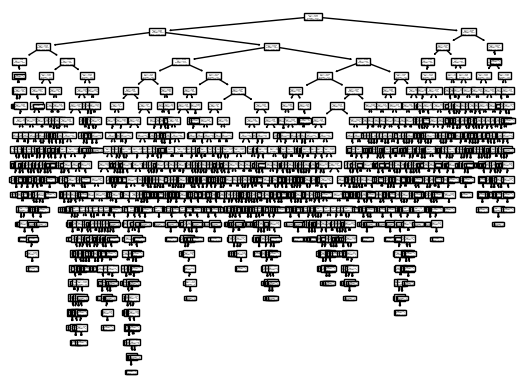

In [44]:
plot_tree(decision_tree=tree)
plt.show()

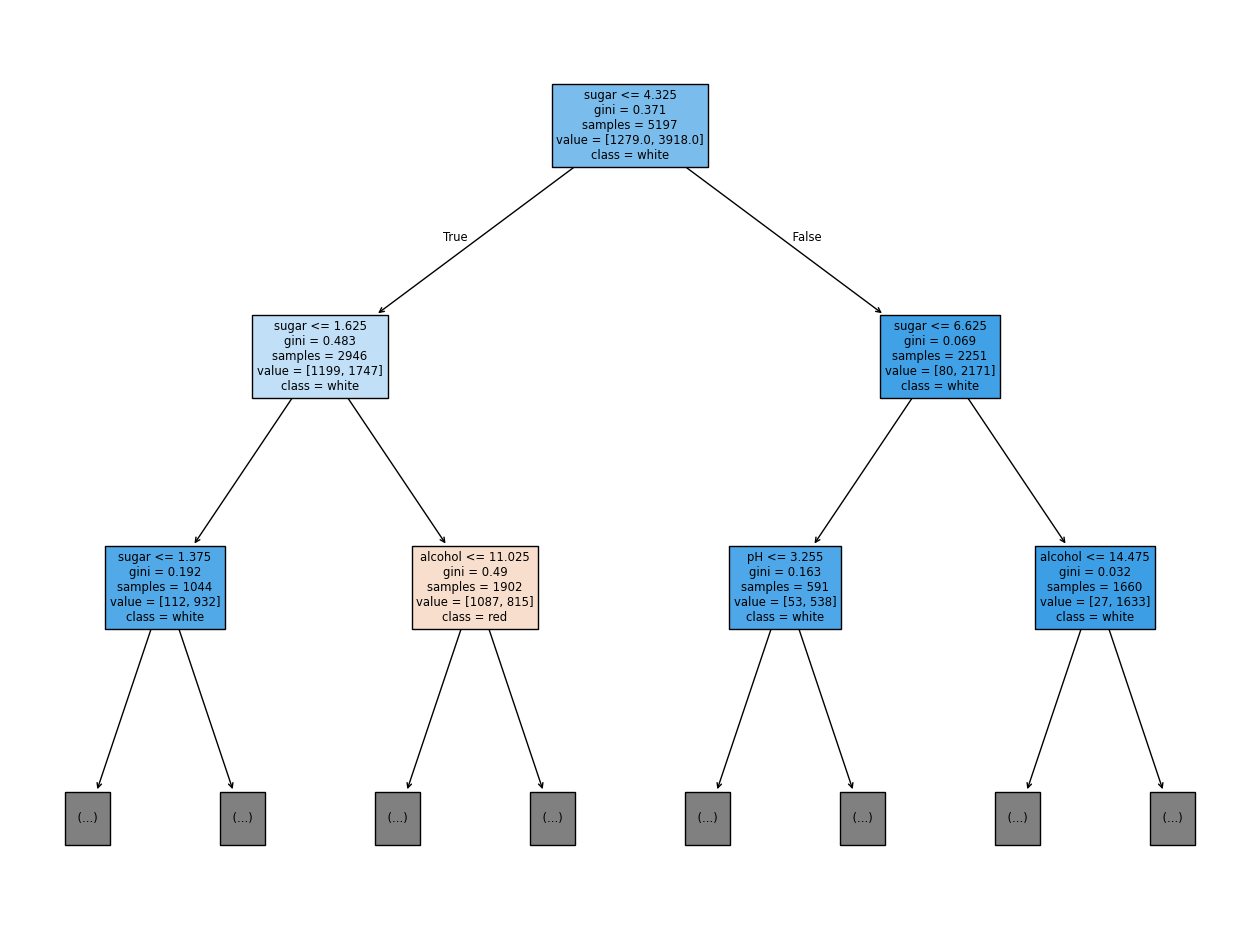

In [47]:
plt.figure(figsize=(16, 12))
plot_tree(decision_tree=tree,           # decision_tree: 훈련이 끝난 tree model
          max_depth=2,                  # max_depth: 시각화할 tree의 깊이(depth)
          feature_names=feature_names,  # feature_names: 특성(변수) 이름들
          class_names=target_names,     # class_names: 타겟 이름들
          filled=True)
plt.show()

**Decision Tree를 나누는 기준**

---

**Gini impurity(Gini 불순도)**

$$
Gini = 1 - \sum_i p_i^2
$$

*   $ p_i $: i번째 클래스가 될 확률
*   이진(binary-class) 분류
    *   $ Gini = 1 - (p_0^2 + p_1^2) $
    *   양성(positive) 또는 음성(negative)으로 완벽하게 분류가 된 경우, $ Gini = 1 - 1 = 0 $.
        *   Gini 불순도 최소.
    *   양성과 음성이 똑같은 비율로 섞여 있는 경우, $ Gini = 1 - (0.5^2 + 0.5^2) = 0.5 $.
        *   Gini 불순도 최대.
    *   양성과 음성의 비율이 6:4인 경우, $ Gini = 1 - (0.6^2 + 0.4^2) = 0.48 $
*   Decision tree는 부모 노드와 자식 노드의 gini 불순도 차이가 가능한 커지도록 가지를 성장시킴.

---

**Entropy(엔트로피)**

$$
Entropy = -\sum_i p_i \log_k (p_i)
$$

*   $k$: 클래스의 개수(이진 분류인 경우, k=2).
*   $p_i$: $i$번째 클래스가 될 확률.
*   이진 분류
    *   양성과 음성의 비율이 1:1인 경우, Entropy = 1. 엔트로피 최대.
    *   양성 또는 음성으로 완벽히 분류된 경우, Entropy = 0. 엔트로피 최소.
*   Decision tree 객체를 생성할 때 criterion='entropy'라고 설정하면, 부모 노드와 자식 노드에서의 엔트로피 차이가 가능하면 커지도록 가지를 생성함.

---

**Decision Tree 특징**

*   장점:
    *   특성들을 스케일링할 필요가 없다.
    *   결과를 이해하기 쉽다.
*   단점:
    *   과대적합(over-fitting)되기가 쉽다.
    *   여러가지 규제들을 적용해서 과대적합 문제를 해결해야 함.
*   규제 하이퍼 파라미터(hyperparameter) - 생성자의 파라미터들
    *   `max_depth`: decision tree의 최대 깊이.
    *   `max_leaf_node`: leaf node의 최댓값.
    *   `max_features`: 각 노드에서 분할에 사용할 특성의 최대 개수.
    *   `min_samples_split`: 노드가 분할되기 위해서 가져야 할 최소 샘플 개수.
    *   `min_samples_leaf`: leaf 노드가 가져야 할 최소 샘플 개수.
    *   `max_`로 시작하는 파라미터의 값을 증가시키면, 트리의 크기가 커짐.
        *   규제가 작아짐.
        *   overfitting이 커짐.
    *   `max_`로 시작하는 파라미터 값을 감소시키면, 트리의 크기가 작아지기 때문에 과대적합(over-fitting)이 작아짐.
    *   `min_`으로 시작하는 파라미터 값을 증가시키면, 트리의 크기가 작아지고 과대적합이 줄어듦.
    *   `min_`으로 시작하는 파라미터 값을 감소시키면, 트리의 크기가 커지고 과대적합이 커짐.


# 하이퍼 파라미터 튜닝

## `max_depth=4` 인 경우

In [48]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)  # ML 모델 생성

In [49]:
tree.fit(X=x_train, y=y_train)  # ML 훈련

DecisionTreeClassifier(max_depth=4, random_state=42)

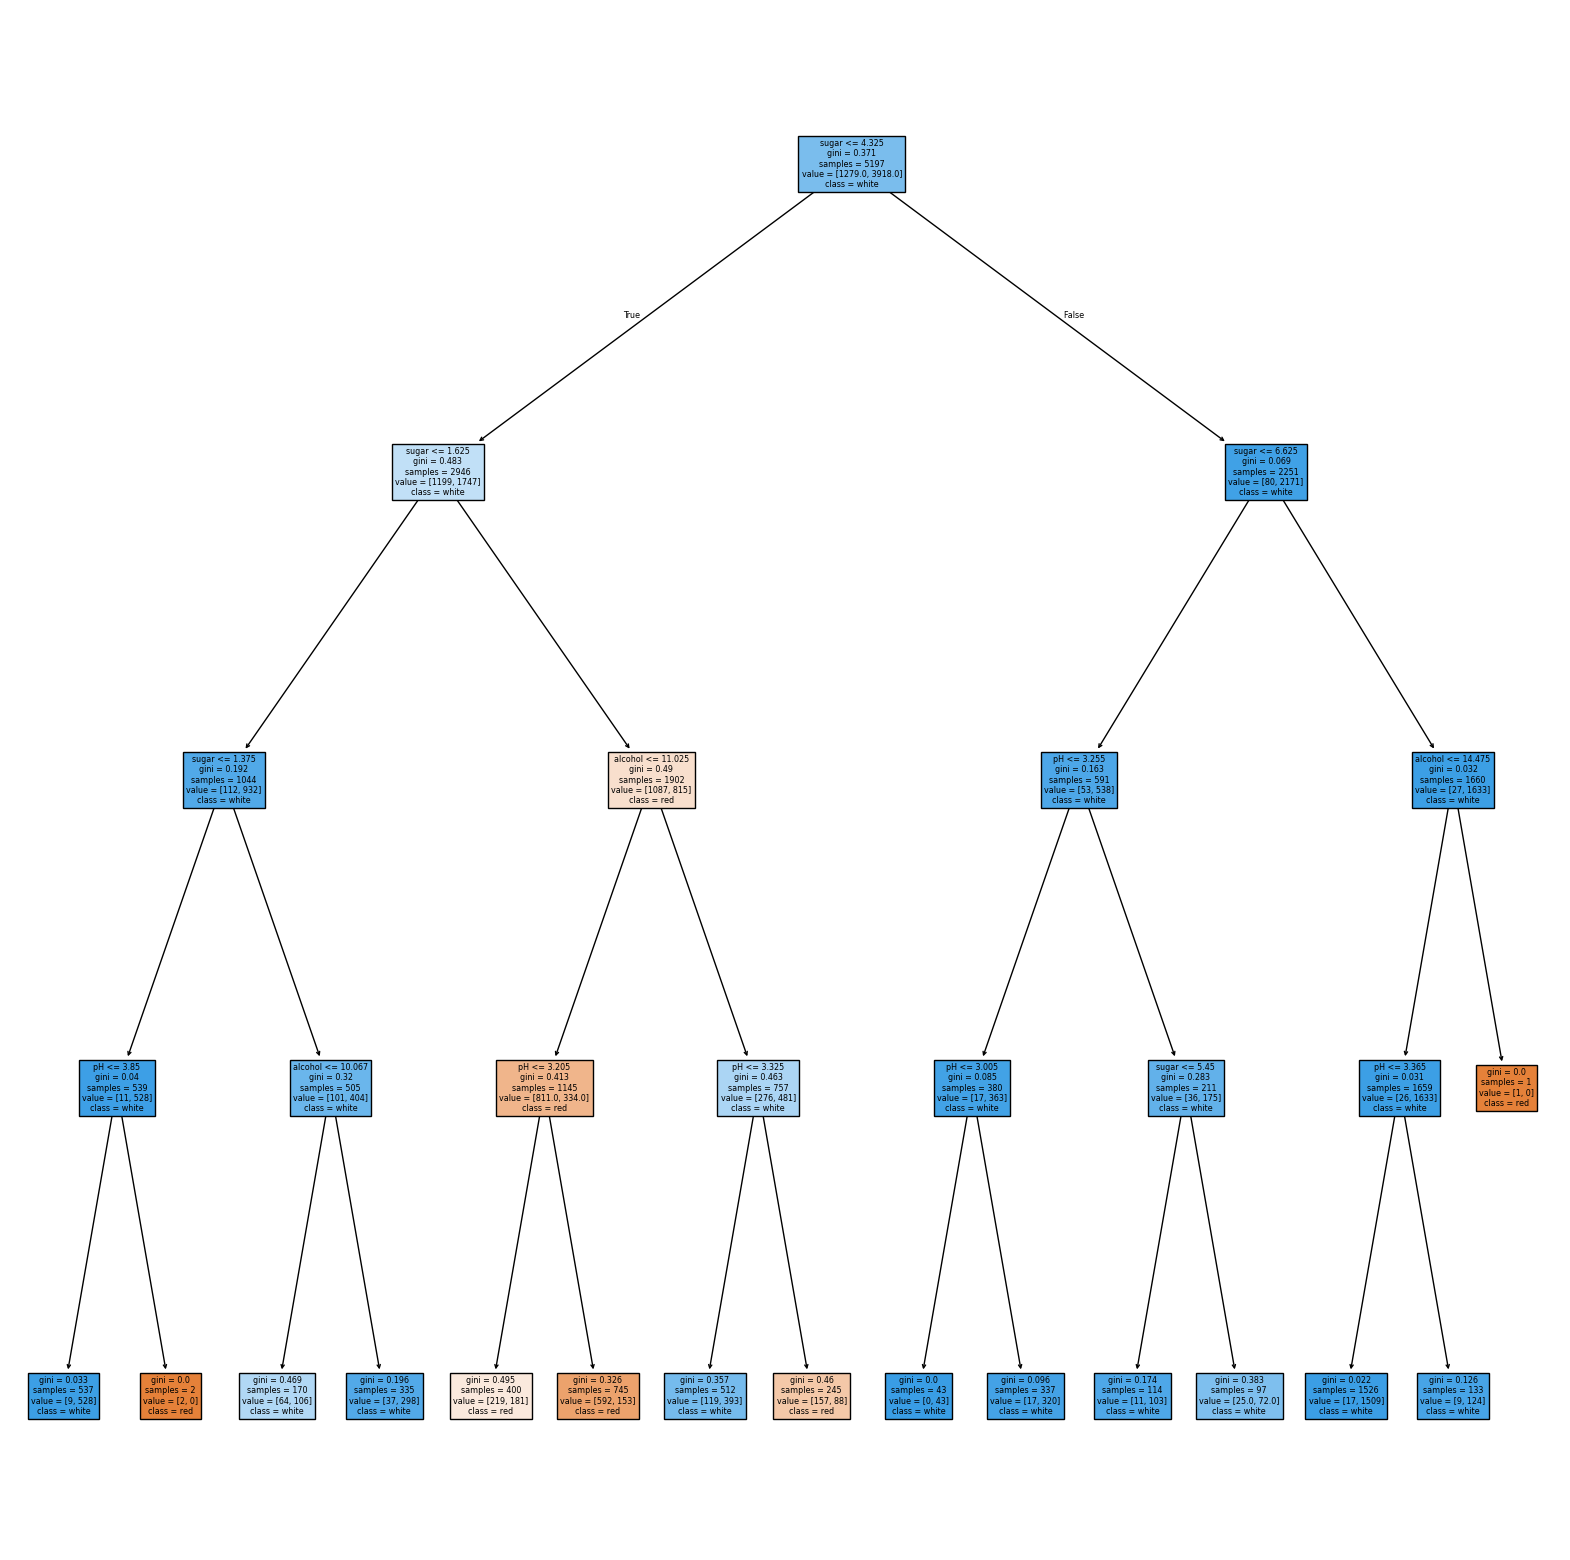

In [50]:
plt.figure(figsize=(20, 20))
plot_tree(decision_tree=tree, feature_names=feature_names, class_names=target_names, filled=True)
plt.show()

In [51]:
print('훈련 셋 정확도 =', tree.score(X=x_train, y=y_train))
print('테스트 셋 정확도 =', tree.score(X=x_test, y=y_test))

훈련 셋 정확도 = 0.8595343467385029
테스트 셋 정확도 = 0.8523076923076923


훈련 셋에서의 정확도를 줄었지만, 과대적합도 줄어듦.